# Spatial Cross-Validated XGBoost

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [2]:
# CONFIG
CITY = "atlanta"
STATE = "13"
COUNTIES = ["121", "089", "067", "135"]

TARGET = "jobs_30min"

N_CLUSTERS = 5

RANDOM_STATE = 42

In [3]:
# LOAD PREDICTORS
X_df = pd.read_parquet(
    f"../data/processed_predictors/atlanta_2023_predictor_dataset.parquet"
)

print("Predictor shape:", X_df.shape)
X_df.head()

Predictor shape: (936, 44)


,tract_id,total_population,population_density,pct_under_18,pct_18_64,pct_over_65,sex_ratio,median_age,avg_household_size,households,...,median_home_value,housing_density,median_year_built,land_area_km2,distance_to_cbd_km,pct_white_non_hispanic,pct_black,pct_hispanic_latino,pct_asian,pct_other_multiracial
0,13089023315,7518,219.008881,0.242219,0.618250,0.139532,0.908606,39.900002,3.16,2362,...,294200.0,70.555931,2003.0,34.327377,29.209461,0.048949,0.865656,0.034717,0.020085,0.030593
1,13089021411,4306,1776.086548,0.203669,0.760334,0.035996,1.209338,31.200001,2.11,2045,...,1028700.0,922.278137,1999.0,2.424431,13.285933,0.700186,0.169066,0.058755,0.021598,0.050395
2,13089021416,2166,1916.231934,0.215605,0.728994,0.055402,0.844974,32.599998,2.27,953,...,550100.0,1009.427795,2001.0,1.130343,11.135415,0.342105,0.080332,0.464451,0.091874,0.021237
3,13135050311,4598,646.479797,0.204654,0.640713,0.154632,0.920635,37.099998,2.48,1832,...,561100.0,281.481628,1997.0,7.112364,26.588184,0.406481,0.262070,0.088952,0.162679,0.079817
4,13089021906,5944,1314.583252,0.243271,0.653600,0.103129,1.096649,34.799999,2.98,1988,...,198000.0,470.852600,1979.0,4.521585,19.912039,0.149394,0.793069,0.026750,0.012281,0.018506


In [4]:
print(X_df.columns.tolist())

['tract_id', 'total_population', 'population_density', 'pct_under_18', 'pct_18_64', 'pct_over_65', 'sex_ratio', 'median_age', 'avg_household_size', 'households', 'median_household_income', 'per_capita_income', 'poverty_rate', 'unemployment_rate', 'labor_force_participation_rate', 'snap_participation_rate', 'public_assistance_rate', 'pct_high_school', 'pct_bachelors_degree', 'pct_graduate_degree', 'pct_no_vehicle_households', 'pct_one_vehicle_households', 'pct_two_plus_vehicle_households', 'median_commute_time', 'pct_public_transit_commute', 'pct_car_commute', 'pct_walk_commute', 'pct_bike_commute', 'pct_work_from_home', 'housing_units', 'occupied_housing_units', 'vacant_housing_units', 'homeownership_rate', 'median_rent', 'median_home_value', 'housing_density', 'median_year_built', 'land_area_km2', 'distance_to_cbd_km', 'pct_white_non_hispanic', 'pct_black', 'pct_hispanic_latino', 'pct_asian', 'pct_other_multiracial']


In [5]:
# LOAD TARGETS
y_df = pd.read_parquet(
    "../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet"
)

print("Target shape:", y_df.shape)
y_df.head()

Target shape: (936, 5)


,from_id,jobs_15min,jobs_30min,jobs_45min,jobs_60min
0,13089023315,0.0,237,410,4133
1,13089021411,3284.0,65304,312772,585144
2,13089021416,6083.0,51009,208101,506445
3,13135050311,8854.0,47665,91329,128484
4,13089021906,666.0,3425,14372,39152


In [6]:
print(y_df.describe())

          jobs_15min     jobs_30min     jobs_45min     jobs_60min
count     936.000000     936.000000     936.000000     936.000000
mean     7081.230769   36113.816239   93439.793803  177958.712607
std     18840.358704   63835.735926  127211.111058  202011.829129
min         0.000000       8.000000     211.000000     602.000000
25%       378.750000    3851.500000   14202.250000   29776.000000
50%      1281.500000   11210.500000   39144.500000   81881.500000
75%      4836.500000   32547.000000  111579.000000  274464.000000
max    159742.000000  311384.000000  588745.000000  761989.000000


In [7]:
# MERGE
df = X_df.merge(
    y_df[["from_id", TARGET]],
    left_on="tract_id",
    right_on="from_id",
    how="inner"
)

print("Merged shape:", df.shape)

Merged shape: (936, 46)


In [8]:
# LOAD TRACT GEOMETRIES
url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)

tracts = tracts[
    tracts["COUNTYFP"].isin(COUNTIES)
].copy()

tracts["tract_id"] = (
    tracts["GEOID"]
    .astype(str)
)

In [9]:
# MERGE GEOMETRIES
df = df.merge(
    tracts[["tract_id", "geometry"]],
    on="tract_id",
    how="left"
)

gdf = gpd.GeoDataFrame(
    df,
    geometry="geometry",
    crs=tracts.crs
)

print(gdf.shape)

(936, 47)


In [10]:
# PROJECT FOR SPATIAL OPERATIONS
split_gdf = gdf.to_crs(
    epsg=5070
).copy()

In [11]:
# CENTROIDS
split_gdf["centroid"] = (
    split_gdf.geometry.centroid
)

split_gdf["x"] = (
    split_gdf.centroid.x
)

split_gdf["y"] = (
    split_gdf.centroid.y
)

In [12]:
# SPATIAL CLUSTERING
coords = np.column_stack([
    split_gdf["x"],
    split_gdf["y"]
])

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init="auto"
)

split_gdf["cluster"] = (
    kmeans.fit_predict(coords)
)

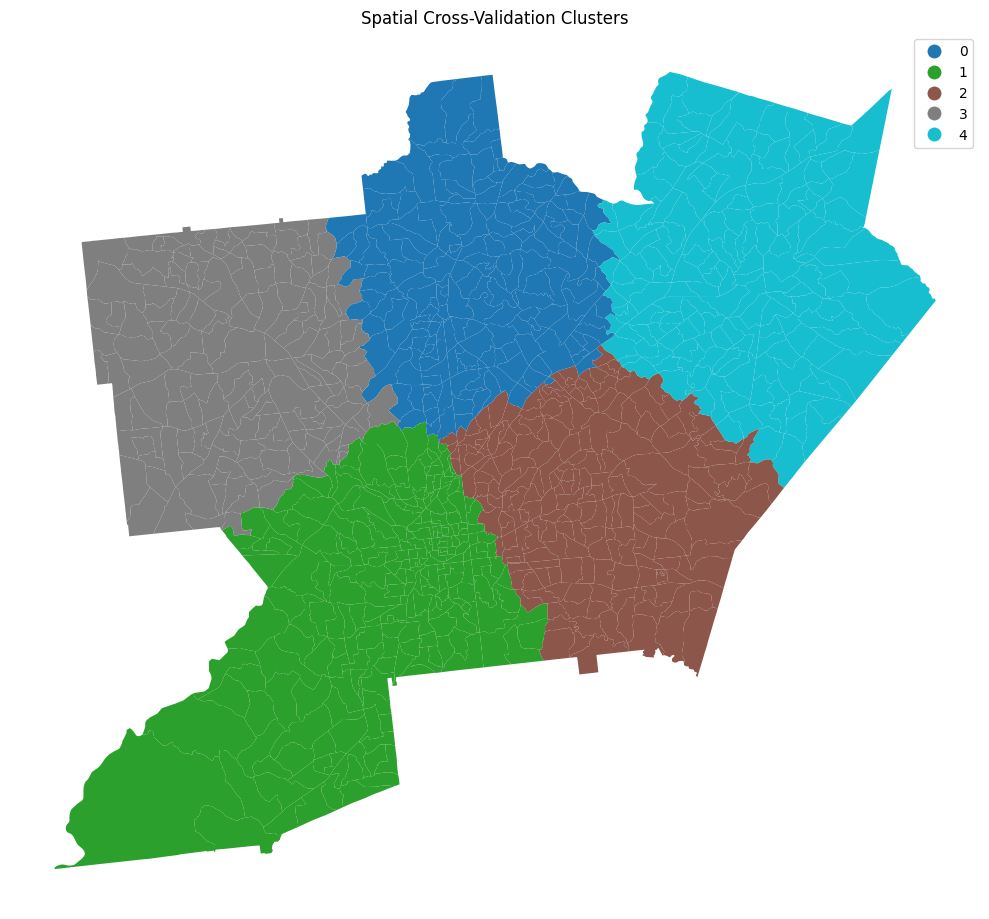

In [13]:
# VISUALIZE SPATIAL FOLDS
fig, ax = plt.subplots(
    figsize=(10, 10)
)

split_gdf.plot(
    column="cluster",
    categorical=True,
    legend=True,
    ax=ax
)

ax.set_title(
    "Spatial Cross-Validation Clusters"
)

ax.axis("off")

plt.tight_layout()

plt.show()

In [14]:
# FEATURES / TARGET
drop_cols = [
    "tract_id",
    "from_id",
    TARGET,
    "geometry",
    "centroid",
    "cluster",
    "x",
    "y"
]

feature_cols = [
    c for c in split_gdf.columns
    if c not in drop_cols
]

X = split_gdf[feature_cols]

# -----------------------------------
# CLEAN FEATURES
# -----------------------------------

# replace inf/-inf
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# optional: inspect problematic columns
bad_counts = X.isna().sum()

print(
    bad_counts[bad_counts > 0]
    .sort_values(ascending=False)
)

# fill missing values
X = X.fillna(0)

# log-transform target
y = np.log1p(
    split_gdf[TARGET]
)

print("Number of features:", len(feature_cols))

median_rent                        87
median_home_value                  29
median_household_income            14
homeownership_rate                  4
vacant_housing_units                4
median_year_built                   4
avg_household_size                  4
pct_no_vehicle_households           4
pct_one_vehicle_households          4
public_assistance_rate              4
pct_two_plus_vehicle_households     4
snap_participation_rate             4
occupied_housing_units              4
pct_walk_commute                    3
pct_car_commute                     3
pct_work_from_home                  3
pct_bike_commute                    3
unemployment_rate                   3
sex_ratio                           3
pct_public_transit_commute          3
pct_over_65                         2
pct_under_18                        2
pct_18_64                           2
median_age                          2
per_capita_income                   2
poverty_rate                        2
labor_force_

In [15]:
# CROSS-VALIDATION
results = []

all_predictions = []

feature_importance_list = []

for test_cluster in range(N_CLUSTERS):

    print("\n" + "=" * 60)

    print(f"TEST CLUSTER: {test_cluster}")

    print("=" * 60)

    # SPATIAL SPLIT
    train_mask = (
        split_gdf["cluster"] != test_cluster
    )

    test_mask = (
        split_gdf["cluster"] == test_cluster
    )

    X_train = X.loc[train_mask]

    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]

    y_test = y.loc[test_mask]

    print("Train size:", len(X_train))

    print("Test size:", len(X_test))

    # MODEL
    model = XGBRegressor(

        n_estimators=500,

        max_depth=4,

        learning_rate=0.03,

        subsample=0.8,

        colsample_bytree=0.8,

        min_child_weight=10,

        reg_lambda=10,

        objective="reg:squarederror",

        random_state=RANDOM_STATE
    )

    # TRAIN
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    # PREDICT
    y_pred_log = model.predict(X_test)

    # back-transform
    y_pred = np.expm1(y_pred_log)

    y_true = np.expm1(y_test)

    # METRICS
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"MAE:  {mae:,.0f}")

    print(f"RMSE: {rmse:,.0f}")

    print(f"R²:   {r2:.4f}")

    # STORE RESULTS
    results.append({

        "cluster": test_cluster,

        "n_test": len(X_test),

        "mae": mae,

        "rmse": rmse,

        "r2": r2
    })

    # STORE PREDICTIONS
    fold_predictions = pd.DataFrame({

        "tract_id":
            split_gdf.loc[test_mask, "tract_id"],

        "cluster":
            test_cluster,

        "actual":
            y_true,

        "predicted":
            y_pred
    })

    all_predictions.append(
        fold_predictions
    )

    # FEATURE IMPORTANCE
    fold_importance = pd.DataFrame({

        "feature":
            feature_cols,

        "importance":
            model.feature_importances_,

        "cluster":
            test_cluster
    })

    feature_importance_list.append(
        fold_importance
    )


TEST CLUSTER: 0
Train size: 762
Test size: 174
MAE:  17,784
RMSE: 27,050
R²:   0.0210

TEST CLUSTER: 1
Train size: 692
Test size: 244
MAE:  67,154
RMSE: 108,415
R²:   -0.1404

TEST CLUSTER: 2
Train size: 736
Test size: 200
MAE:  11,082
RMSE: 20,463
R²:   0.4543

TEST CLUSTER: 3
Train size: 778
Test size: 158
MAE:  8,063
RMSE: 14,049
R²:   0.5239

TEST CLUSTER: 4
Train size: 776
Test size: 160
MAE:  5,499
RMSE: 8,383
R²:   0.3062


In [16]:
# RESULTS
results_df = pd.DataFrame(results)

results_df

,cluster,n_test,mae,rmse,r2
0,0,174,17783.847209,27049.674642,0.021042
1,1,244,67153.931277,108414.640993,-0.140413
2,2,200,11081.785897,20462.545888,0.454349
3,3,158,8063.479097,14049.207033,0.523856
4,4,160,5499.067140,8382.583031,0.306173


In [17]:
# OVERALL PERFORMANCE
print("\nOVERALL PERFORMANCE")

print("-" * 40)

print(
    results_df[
        ["mae", "rmse", "r2"]
    ].mean()
)


OVERALL PERFORMANCE
----------------------------------------
mae     21916.422124
rmse    35671.730317
r2          0.233002
dtype: float64


In [18]:
# RESULTS SUMMARY
results_df.describe()

,cluster,n_test,mae,rmse,r2
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,187.200000,21916.422124,35671.730317,0.233002
std,1.581139,35.905431,25701.815729,41259.608764,0.284302
min,0.000000,158.000000,5499.067140,8382.583031,-0.140413
25%,1.000000,160.000000,8063.479097,14049.207033,0.021042
50%,2.000000,174.000000,11081.785897,20462.545888,0.306173
75%,3.000000,200.000000,17783.847209,27049.674642,0.454349
max,4.000000,244.000000,67153.931277,108414.640993,0.523856


In [19]:
# CONCATENATE PREDICTIONS
predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

predictions_df.head()
# predictions_df.describe()

,tract_id,cluster,actual,predicted
0,13135050311,0,47665.0,9173.600586
1,13121010108,0,1101.0,10614.687500
2,13067030332,0,11945.0,3368.043213
3,13067030322,0,5426.0,7542.805664
4,13067030319,0,5891.0,5649.572266


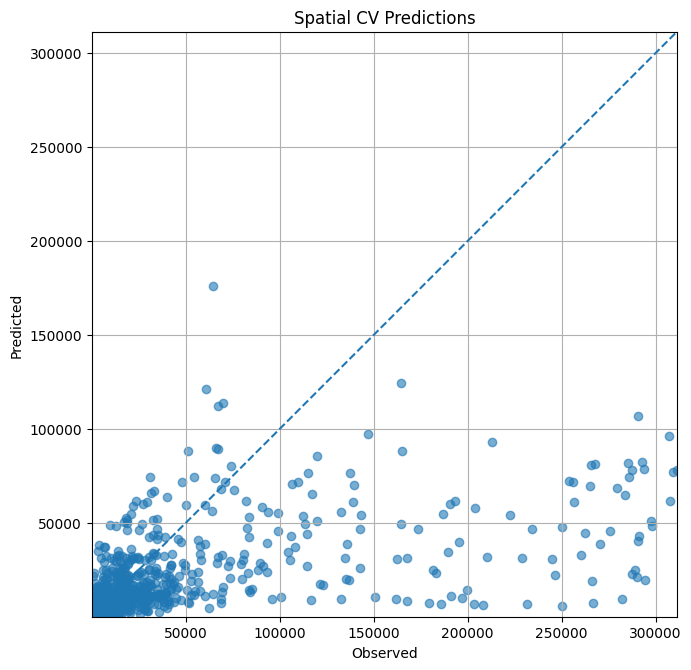

In [20]:
# PREDICTION SCATTERPLOT
fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.scatter(
    predictions_df["actual"],
    predictions_df["predicted"],
    alpha=0.6
)

min_val = min(
    predictions_df["actual"].min(),
    predictions_df["predicted"].min()
)

max_val = max(
    predictions_df["actual"].max(),
    predictions_df["predicted"].max()
)

# perfect prediction line
ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

ax.set_xlim(min_val, max_val)

ax.set_ylim(min_val, max_val)

ax.set_aspect("equal")

ax.set_xlabel("Observed")

ax.set_ylabel("Predicted")

ax.set_title(
    "Spatial CV Predictions"
)

ax.grid(True)

plt.tight_layout()

plt.show()

In [21]:
# FEATURE IMPORTANCE
importance_df = pd.concat(
    feature_importance_list,
    ignore_index=True
)

importance_summary = (

    importance_df

    .groupby("feature")["importance"]

    .mean()

    .sort_values(
        ascending=False
    )

    .reset_index()
)

importance_summary.head(20)

,feature,importance
0,housing_density,0.174467
1,distance_to_cbd_km,0.114425
2,homeownership_rate,0.064137
3,land_area_km2,0.061119
4,avg_household_size,0.058883
5,pct_black,0.055996
6,per_capita_income,0.027801
7,pct_asian,0.022805
8,median_year_built,0.022675
9,population_density,0.021688


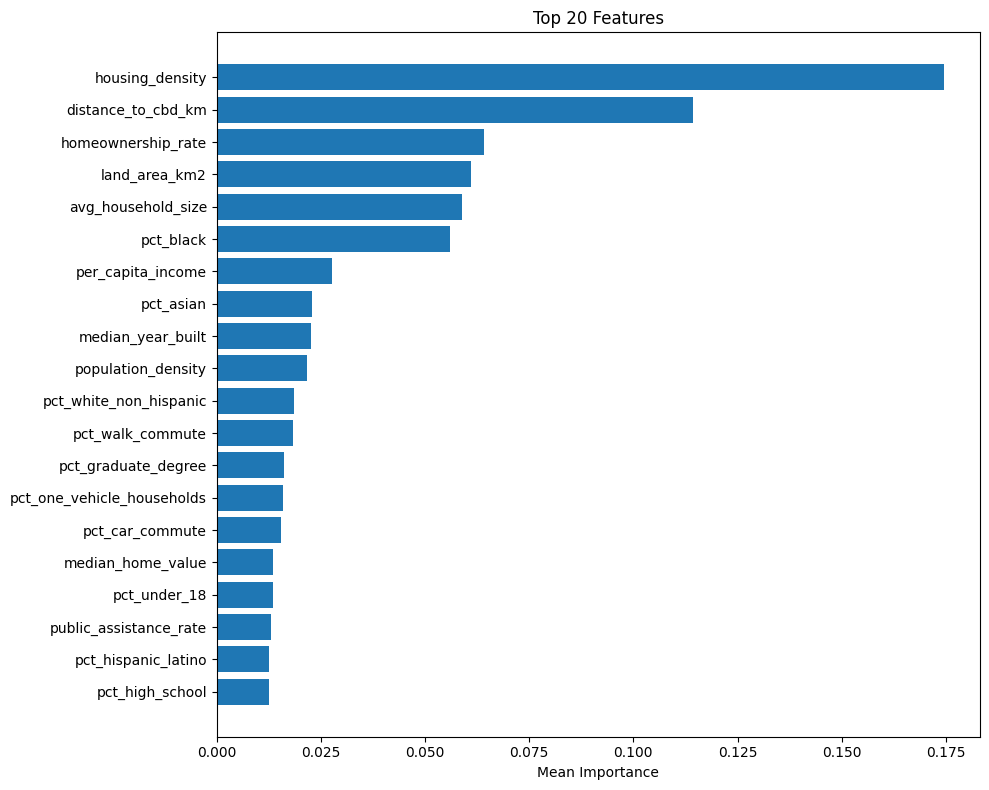

In [22]:
# FEATURE IMPORTANCE PLOT
top_n = 20

plot_df = (
    importance_summary
    .head(top_n)
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

ax.set_xlabel(
    "Mean Importance"
)

ax.set_title(
    f"Top {top_n} Features"
)

plt.tight_layout()

plt.show()

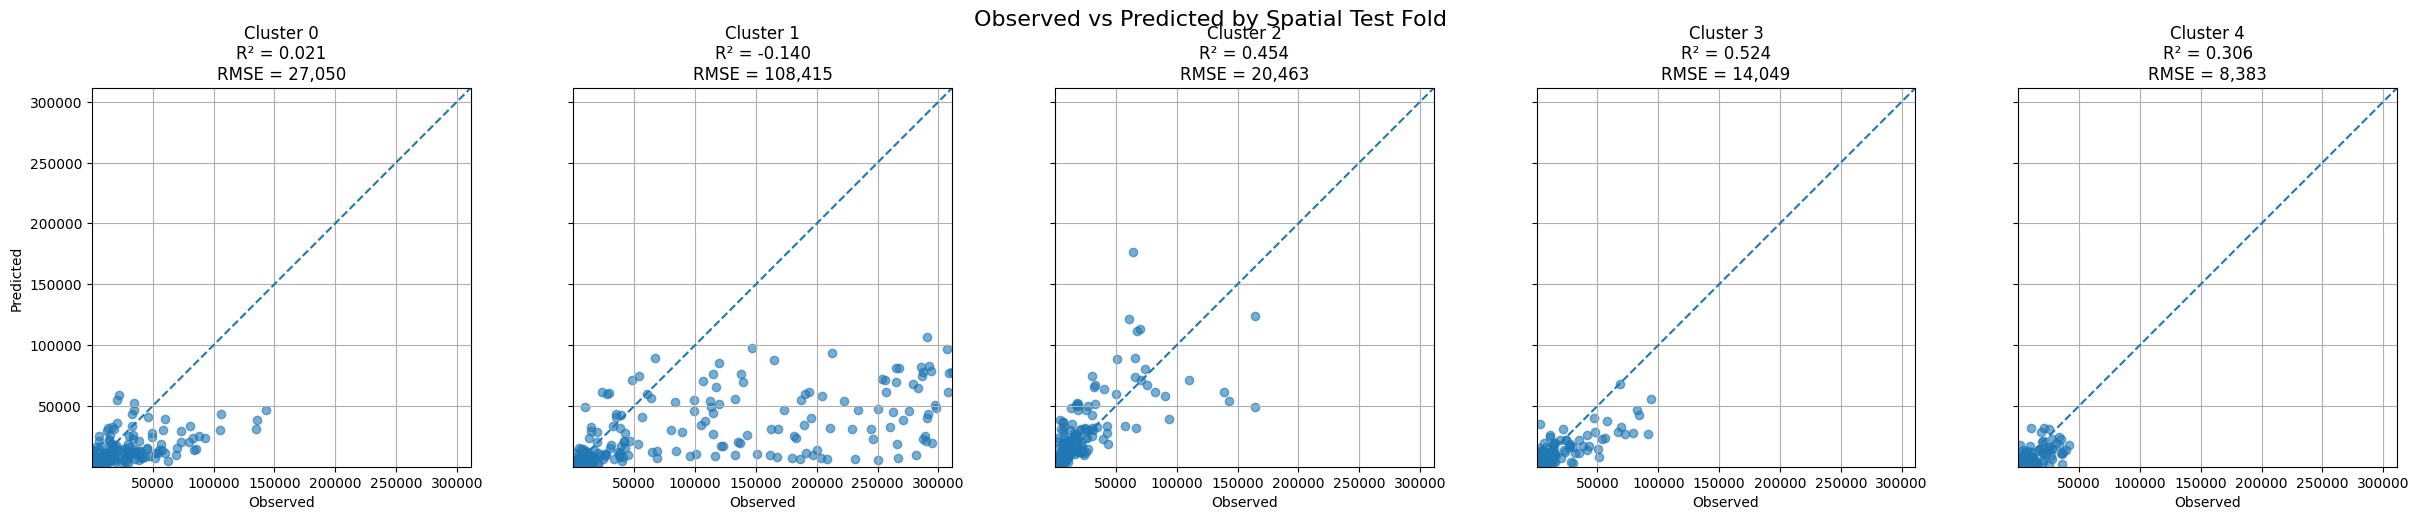

In [23]:
# %%
# OBSERVED VS PREDICTED PER SPATIAL FOLD

fig, axes = plt.subplots(
    nrows=1,
    ncols=N_CLUSTERS,
    figsize=(5 * N_CLUSTERS, 5),
    sharex=True,
    sharey=True
)

# handle case when only 1 cluster
if N_CLUSTERS == 1:
    axes = [axes]

global_min = min(
    predictions_df["actual"].min(),
    predictions_df["predicted"].min()
)

global_max = max(
    predictions_df["actual"].max(),
    predictions_df["predicted"].max()
)

for cluster_id, ax in enumerate(axes):

    fold_df = predictions_df[
        predictions_df["cluster"] == cluster_id
    ]

    ax.scatter(
        fold_df["actual"],
        fold_df["predicted"],
        alpha=0.6
    )

    # perfect prediction line
    ax.plot(
        [global_min, global_max],
        [global_min, global_max],
        linestyle="--"
    )

    # fold metrics
    fold_r2 = r2_score(
        fold_df["actual"],
        fold_df["predicted"]
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            fold_df["actual"],
            fold_df["predicted"]
        )
    )

    ax.set_title(
        f"Cluster {cluster_id}\n"
        f"R² = {fold_r2:.3f}\n"
        f"RMSE = {fold_rmse:,.0f}"
    )

    ax.set_xlim(global_min, global_max)

    ax.set_ylim(global_min, global_max)

    ax.set_aspect("equal")

    ax.grid(True)

    ax.set_xlabel("Observed")

    if cluster_id == 0:
        ax.set_ylabel("Predicted")

plt.suptitle(
    "Observed vs Predicted by Spatial Test Fold",
    fontsize=16
)

plt.tight_layout()

plt.show()